In [2]:
# Block 1: Install libraries and set up environment

!pip install rdkit scikit-learn pandas openpyxl torch -q

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors, Draw
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display
import random
import re
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Libraries installed and imported successfully")
print(f"Device being used: {device}")
print(f"PyTorch version: {torch.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 62.2 MB/s eta 0:00:00
Libraries installed and imported successfully
Device being used: cuda
PyTorch version: 2.11.0+cu128


Meaning of Block 1:

!pip install torch — installs PyTorch, the deep learning framework used to build and train our LSTM. PyTorch is developed by Meta and is the most widely used deep learning framework in pharmaceutical AI research worldwide. All neural network operations in this practical run through PyTorch.
import torch.nn as nn — loads PyTorch's neural network module containing all building blocks: LSTM layers, linear layers, embedding layers, loss functions, and optimizers — everything needed to construct and train our generative model.
from torch.utils.data import Dataset, DataLoader — loads PyTorch's data pipeline tools. Dataset defines how SMILES data is structured for training; DataLoader feeds it to the model efficiently in batches, handling shuffling and parallel data loading automatically.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') — detects whether GPU is available. Since T4 GPU is enabled, this prints cuda — all tensor operations and neural network training will run on the GPU, making LSTM training approximately 15–20x faster than CPU.
All other imports (RDKit, scikit-learn, pandas, numpy) are familiar from Practicals 1–3 — same tools, same purpose.

In [3]:
# Block 2: Load EGFR ChEMBL data, clean, and build RF scoring model

print("="*55)
print("PHASE 1: BUILDING RF SCORING MODEL")
print("="*55)

egfr_url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/QSAR_EGFR_bioactivity_data.xlsx"

print("Loading EGFR ChEMBL dataset...")
df_egfr = pd.read_excel(egfr_url)
print("Raw EGFR dataset shape:", df_egfr.shape)

df_egfr = df_egfr[df_egfr['standard_units'] == 'nM'].copy()
df_egfr['pIC50'] = -np.log10(df_egfr['standard_value'].astype(float) * 1e-9)
df_egfr = df_egfr.groupby('canonical_smiles', as_index=False).agg({
    'molecule_chembl_id': 'first',
    'pIC50': 'mean'
})

print("After cleaning:", df_egfr.shape)

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(str(smiles).strip())
    if mol is None:
        return None
    return morgan_gen.GetFingerprintAsNumPy(mol)

df_egfr['fingerprint'] = df_egfr['canonical_smiles'].apply(get_fingerprint)
df_egfr = df_egfr[df_egfr['fingerprint'].notnull()].copy()

X = np.stack(df_egfr['fingerprint'].values)
y = df_egfr['pIC50'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training RF scoring model...")
rf_model = RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("="*55)
print("RF Scoring Model Ready")
print(f"RMSE: {rmse:.3f}")
print(f"R2 Score: {r2:.3f}")
print("="*55)

PHASE 1: BUILDING RF SCORING MODEL
Loading EGFR ChEMBL dataset...
Raw EGFR dataset shape: (25180, 5)
After cleaning: (13577, 3)
Training RF scoring model...
RF Scoring Model Ready
RMSE: 0.734
R2 Score: 0.736


Meaning of Block 2:

This block serves two purposes simultaneously — building the RF scoring model AND preparing the cleaned EGFR dataset that will be used again in Block 3 for extracting the fine-tuning set.
egfr_url — your GitHub-hosted EGFR ChEMBL Excel file — 25,180 rows of experimental IC50 measurements for EGFR inhibitors.
The three cleaning steps (unit filter → pIC50 conversion → duplicate averaging) are condensed here since they were taught in detail in Practicals 1–3. Expected shape after cleaning: approximately (13577, 3).
n_jobs=-1 — tells scikit-learn to use all available CPU cores simultaneously for RF training, making it significantly faster than default single-core training.
Why RF model is built first: this scoring function is our compass for evaluating generated molecules later. Every novel molecule the LSTM generates in Block 8 will be passed through this RF model to get a predicted pIC50 — without it we'd have no way to distinguish promising molecules from useless ones.
Expected results: RMSE ≈ 0.734, R² ≈ 0.736 — matching all previous practicals since identical data, fingerprints, and algorithm are used.

In [4]:
# Block 3: Extract EGFR fine-tuning set and load pre-training corpus

print("="*55)
print("PHASE 2: PREPARING LSTM TRAINING DATA")
print("="*55)

# Extract EGFR fine-tuning set (most potent inhibitors only)
finetune_threshold = 7.0
df_finetune = df_egfr[df_egfr['pIC50'] >= finetune_threshold].copy()
df_finetune = df_finetune[['canonical_smiles']].drop_duplicates().reset_index(drop=True)

print(f"EGFR fine-tuning set (pIC50 >= {finetune_threshold}):")
print(f"Number of potent EGFR inhibitors: {len(df_finetune)}")
print(f"These represent IC50 <= 100 nM compounds")

# Load pre-training corpus
print("\nLoading MOSES pre-training corpus...")
corpus_url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/denovo%20drug%20design.xlsx"
df_corpus = pd.read_excel(corpus_url)
df_corpus = df_corpus[['canonical_smiles']].dropna().drop_duplicates()

print(f"Pre-training corpus size: {len(df_corpus)} molecules")

print("\nSample EGFR fine-tuning SMILES:")
print(df_finetune['canonical_smiles'].head(3).values)
print("\nSample pre-training corpus SMILES:")
print(df_corpus['canonical_smiles'].head(3).values)

print("="*55)
print("Data preparation complete")
print(f"Pre-training corpus: {len(df_corpus)} diverse drug-like molecules")
print(f"Fine-tuning set: {len(df_finetune)} potent EGFR inhibitors")
print("="*55)

PHASE 2: PREPARING LSTM TRAINING DATA
EGFR fine-tuning set (pIC50 >= 7.0):
Number of potent EGFR inhibitors: 6210
These represent IC50 <= 100 nM compounds

Loading MOSES pre-training corpus...
Pre-training corpus size: 50000 molecules

Sample EGFR fine-tuning SMILES:
['Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccccc1'
 'Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(Br)cc1'
 'Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(F)cc1']

Sample pre-training corpus SMILES:
['COc1ccc(Br)c(CNC(=O)Cc2cccs2)c1' 'O=C(c1cccc(F)c1)N(Cc1cccnc1)Cc1ccco1'
 'Cc1ccc(NC(=O)CCn2c(=O)oc3ccccc32)cc1']
Data preparation complete
Pre-training corpus: 50000 diverse drug-like molecules
Fine-tuning set: 6210 potent EGFR inhibitors


Meaning of Block 3:

finetune_threshold = 7.0 — filters only the most potent EGFR inhibitors from our cleaned dataset. pIC50 ≥ 7.0 corresponds to IC50 ≤ 100 nM — these are genuinely potent compounds that clearly bind EGFR well. Using only the top-quality compounds for fine-tuning ensures the LSTM learns the strongest, most characteristic EGFR pharmacophore patterns rather than being diluted by weakly active compounds.
df_finetune = df_egfr[df_egfr['pIC50'] >= finetune_threshold] — this extracts our fine-tuning set from the same df_egfr dataframe already cleaned and averaged in Block 2 — no reloading needed.
df_finetune[['canonical_smiles']] — keeps only SMILES for fine-tuning — the LSTM only needs molecular structures, not pIC50 values. The LSTM is not learning to predict activity; it's learning to generate molecules that look like active EGFR inhibitors.
corpus_url — your GitHub-hosted MOSES corpus file (denovo drug design.xlsx) — 50,000 diverse drug-like SMILES spanning broad chemical space, used to teach the LSTM general SMILES grammar before it specializes in EGFR chemistry.
The contrast between the two datasets is the heart of transfer learning: the corpus (50,000 diverse molecules) gives broad chemical language competence; the fine-tuning set (potent EGFR inhibitors) gives EGFR-specific chemical knowledge. The LSTM needs both — one without the other produces either valid-but-random molecules (corpus only) or EGFR-like-but-invalid molecules (fine-tuning only).  


https://media.githubusercontent.com/media/molecularsets/moses/master/data/dataset_v1.csv

Above is the original location of the excel file. The pre-training corpus (denovo drug design.xlsx) was prepared separately by sampling 50,000 drug-like molecules from the MOSES benchmark dataset (1,936,962 molecules total) using:

df_corpus = df_corpus.sample(n=50000, random_state=42)

This excel file (named denovo drug design with 50000 molecules out of 1936962) is permanently hosted on GitHub and loaded directly here — no re-sampling needed each session.


In [5]:
# Block 4: Build SMILES vocabulary and tokenizer

def build_vocabulary(smiles_list):
    all_chars = set()
    for smi in smiles_list:
        all_chars.update(list(str(smi)))

    special_tokens = ['<PAD>', '<SOS>', '<EOS>']
    vocab = special_tokens + sorted(list(all_chars))

    char_to_idx = {char: idx for idx, char in enumerate(vocab)}
    idx_to_char = {idx: char for char, idx in char_to_idx.items()}

    return vocab, char_to_idx, idx_to_char

all_smiles = pd.concat([
    df_corpus['canonical_smiles'],
    df_finetune['canonical_smiles']
]).dropna().unique().tolist()

vocab, char_to_idx, idx_to_char = build_vocabulary(all_smiles)

PAD_IDX = char_to_idx['<PAD>']
SOS_IDX = char_to_idx['<SOS>']
EOS_IDX = char_to_idx['<EOS>']

print("="*55)
print("SMILES VOCABULARY BUILT")
print("="*55)
print(f"Vocabulary size: {len(vocab)} unique characters")
print(f"Characters: {sorted([c for c in vocab if not c.startswith('<')])}")
print(f"PAD token index: {PAD_IDX}")
print(f"SOS token index: {SOS_IDX}")
print(f"EOS token index: {EOS_IDX}")
print("="*55)

SMILES VOCABULARY BUILT
Vocabulary size: 38 unique characters
Characters: ['#', '(', ')', '+', '-', '.', '/', '1', '2', '3', '4', '5', '6', '7', '=', '@', 'B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S', '[', '\\', ']', 'c', 'e', 'l', 'n', 'o', 'r', 's']
PAD token index: 0
SOS token index: 1
EOS token index: 2


Meaning of Block 4:

build_vocabulary(smiles_list) — scans every character in every SMILES string across both datasets and builds a complete vocabulary of all unique characters that appear. This is exactly how language models build their vocabulary — by cataloguing every unique "letter" in the training text.
all_chars = set() — a Python set automatically stores only unique characters. As we loop through every SMILES string and update with every character, duplicates are automatically ignored — we end up with one entry per unique character.
special_tokens = ['<PAD>', '<SOS>', '<EOS>'] — three special tokens essential for sequence modeling:
<PAD> (Padding) — used to make all SMILES strings the same length for batch processing, since different molecules have different length SMILES
<SOS> (Start of Sequence) — placed at the beginning of every SMILES string during training, telling the model "a new molecule is starting"
<EOS> (End of Sequence) — placed at the end of every SMILES string, telling the model "this molecule is complete" — during generation, the model stops writing when it predicts an EOS token
char_to_idx and idx_to_char — two lookup dictionaries converting between characters and numbers. The LSTM cannot process text directly — it needs numbers. Every character gets a unique integer ID. char_to_idx converts 'C' → 5 (for example); idx_to_char converts 5 → 'C' — needed when converting the model's numerical output back into readable SMILES.
pd.concat([df_corpus['canonical_smiles'], df_finetune['canonical_smiles']]) — builds vocabulary from BOTH datasets combined — this ensures every character that appears in either the pre-training corpus OR the fine-tuning EGFR set is included. If we built vocabulary from only one dataset, characters unique to the other might be missing, causing errors during training.
vocab size — the total number of unique characters found across all SMILES plus the 3 special tokens. Typically 35–45 for drug-like SMILES — a tiny vocabulary compared to English (26 letters + punctuation) but sufficient since chemical SMILES use a small, well-defined character set.

In [6]:
# Block 5: Create PyTorch Dataset and DataLoader

class SMILESDataset(Dataset):
    def __init__(self, smiles_list, char_to_idx, max_len=120):
        self.smiles_list = smiles_list
        self.char_to_idx = char_to_idx
        self.max_len = max_len
        self.pad_idx = char_to_idx['<PAD>']
        self.sos_idx = char_to_idx['<SOS>']
        self.eos_idx = char_to_idx['<EOS>']

    def __len__(self):
        return len(self.smiles_list)

    def __getitem__(self, idx):
        smi = str(self.smiles_list[idx])

        encoded = [self.sos_idx] + \
                  [self.char_to_idx.get(c, self.pad_idx) for c in smi] + \
                  [self.eos_idx]

        if len(encoded) > self.max_len:
            encoded = encoded[:self.max_len]

        padded = encoded + [self.pad_idx] * (self.max_len - len(encoded))

        input_seq = torch.tensor(padded[:-1], dtype=torch.long)
        target_seq = torch.tensor(padded[1:], dtype=torch.long)

        return input_seq, target_seq

corpus_smiles = df_corpus['canonical_smiles'].dropna().tolist()
corpus_dataset = SMILESDataset(corpus_smiles, char_to_idx)
corpus_loader = DataLoader(
    corpus_dataset, batch_size=256, shuffle=True, num_workers=2
)

finetune_smiles = df_finetune['canonical_smiles'].dropna().tolist()
finetune_dataset = SMILESDataset(finetune_smiles, char_to_idx)
finetune_loader = DataLoader(
    finetune_dataset, batch_size=64, shuffle=True, num_workers=2
)

print("="*55)
print("PYTORCH DATASETS AND DATALOADERS READY")
print("="*55)
print(f"Pre-training dataset size: {len(corpus_dataset)} molecules")
print(f"Pre-training batch size: 256")
print(f"Fine-tuning dataset size: {len(finetune_dataset)} molecules")
print(f"Fine-tuning batch size: 64")
print(f"Max SMILES length: 120 characters")
print("="*55)

PYTORCH DATASETS AND DATALOADERS READY
Pre-training dataset size: 50000 molecules
Pre-training batch size: 256
Fine-tuning dataset size: 6210 molecules
Fine-tuning batch size: 64
Max SMILES length: 120 characters


Meaning of Block 5:

class SMILESDataset(Dataset) — defines a custom PyTorch Dataset class that handles how SMILES strings are prepared for the LSTM. It inherits from PyTorch's built-in Dataset class — a standard pattern in all PyTorch projects.
__len__ — returns the total number of molecules in the dataset — PyTorch uses this to know when one full pass through the data (one epoch) is complete.
__getitem__(self, idx) — defines how one single SMILES string is prepared for training. For each molecule:
Prepend <SOS> token — signals "start generating"
Convert each character to its integer ID using char_to_idx
Append <EOS> token — signals "stop generating"
Truncate to max_len=120 if longer
Pad with <PAD> tokens to reach exactly max_len
input_seq = padded[:-1] and target_seq = padded[1:] — this is the key training mechanic. For each position in the SMILES, the model sees the current character (input_seq) and must predict the next character (target_seq). For example, if the SMILES is "CCO": input = [SOS, C, C] → target = [C, C, O]; input = [C, C, O] → target = [C, O, EOS]. The model learns: "given what I've seen so far, what comes next?"
DataLoader(corpus_dataset, batch_size=256, shuffle=True) — wraps the dataset for efficient batch training. batch_size=256 means 256 molecules are processed simultaneously per GPU step — large batches are faster on GPU. shuffle=True randomizes molecule order each epoch, preventing the model from memorizing sequence order rather than learning chemistry.
Two separate DataLoaders — one for pre-training (batch_size=256, larger for speed) and one for fine-tuning (batch_size=64, smaller since fine-tuning dataset is much smaller and we want more careful, gradual weight updates).

In [7]:
# Block 6: Build the LSTM generative model architecture

class MolecularLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128,
                 hidden_dim=512, num_layers=3, dropout=0.2):
        super(MolecularLSTM, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=PAD_IDX
        )
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, x, hidden=None):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.lstm(embedded, hidden)
        output = self.dropout(output)
        logits = self.fc(output)
        return logits, hidden

    def init_hidden(self, batch_size):
        return (
            torch.zeros(self.num_layers, batch_size,
                       self.hidden_dim).to(device),
            torch.zeros(self.num_layers, batch_size,
                       self.hidden_dim).to(device)
        )

vocab_size = len(vocab)
model = MolecularLSTM(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=512,
    num_layers=3,
    dropout=0.2
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)

print("="*55)
print("LSTM MODEL ARCHITECTURE")
print("="*55)
print(model)
print("="*55)
print(f"Vocabulary size: {vocab_size}")
print(f"Embedding dimension: 128")
print(f"Hidden dimension: 512")
print(f"Number of LSTM layers: 3")
print(f"Dropout rate: 0.2")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model device: {next(model.parameters()).device}")
print("="*55)

LSTM MODEL ARCHITECTURE
MolecularLSTM(
  (embedding): Embedding(38, 128, padding_idx=0)
  (lstm): LSTM(128, 512, num_layers=3, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=512, out_features=38, bias=True)
)
Vocabulary size: 38
Embedding dimension: 128
Hidden dimension: 512
Number of LSTM layers: 3
Dropout rate: 0.2
Total parameters: 5,541,670
Trainable parameters: 5,541,670
Model device: cuda:0


Meaning of Block 6:

class MolecularLSTM(nn.Module) — defines our LSTM model architecture. Inheriting from nn.Module is mandatory for all PyTorch models — it gives access to all PyTorch's training infrastructure.
nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX) — converts integer character IDs into dense numerical vectors of size embed_dim=128. Instead of representing 'C' as just the number 5, it represents it as a 128-dimensional vector that captures semantic relationships between characters — similar characters (like 'c' lowercase aromatic carbon and 'C' uppercase aliphatic carbon) will have similar embedding vectors after training.
nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout) — the core LSTM layer. Three stacked LSTM layers (num_layers=3) with 512 hidden units each. Stacking multiple LSTM layers allows the model to learn hierarchical patterns — lower layers learn simple character patterns (what characters commonly follow each other), higher layers learn more complex chemical patterns (ring closures, branch structures, functional groups).
nn.Linear(hidden_dim, vocab_size) — the final output layer that converts each LSTM hidden state (512 numbers) into a probability distribution over all vocabulary characters (vocab_size numbers). The character with the highest probability is the model's prediction for "what comes next."
dropout=0.2 — randomly deactivates 20% of neurons during training, preventing the model from memorizing the training data too closely (overfitting) — essential for a model that must generalize to generate truly novel molecules.
forward(self, x, hidden=None) — defines the forward pass: input characters → embedding → LSTM → dropout → linear layer → output probability distribution over next characters.
init_hidden(batch_size) — initializes LSTM's memory (hidden state and cell state) to zeros at the start of each batch — the model starts with no memory at the beginning of each new sequence.
.to(device) — moves the entire model (all weights, all layers) to the GPU — essential for fast training.
total_params — counts all learnable numbers in the model. Expect approximately 3–5 million parameters — a relatively small model by modern standards (GPT-3 has 175 billion) but entirely appropriate for learning SMILES grammar from 50,000 molecules.

In [8]:
# Block 7: Pre-train LSTM on large diverse SMILES corpus

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_tokens = 0

    for batch_idx, (input_seq, target_seq) in enumerate(loader):
        input_seq = input_seq.to(device)
        target_seq = target_seq.to(device)

        optimizer.zero_grad()
        hidden = model.init_hidden(input_seq.size(0))

        logits, _ = model(input_seq, hidden)

        loss = criterion(
            logits.view(-1, len(vocab)),
            target_seq.view(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * target_seq.numel()
        total_tokens += target_seq.numel()

    return total_loss / total_tokens

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.5
)

print("="*55)
print("PHASE 2A: PRE-TRAINING ON DIVERSE CORPUS")
print("="*55)
print(f"Training on {len(corpus_dataset)} diverse drug-like molecules")
print(f"Goal: Learn general SMILES grammar and chemical language")
print("="*55)

pretrain_epochs = 10
pretrain_losses = []

for epoch in range(1, pretrain_epochs + 1):
    loss = train_epoch(
        model, corpus_loader, optimizer, criterion, device
    )
    pretrain_losses.append(loss)
    scheduler.step()
    print(f"Pre-training Epoch {epoch}/{pretrain_epochs} "
          f"— Loss: {loss:.4f} "
          f"— LR: {scheduler.get_last_lr()[0]:.6f}")

print("="*55)
print("Pre-training complete")
print(f"Final pre-training loss: {pretrain_losses[-1]:.4f}")
print("="*55)

PHASE 2A: PRE-TRAINING ON DIVERSE CORPUS
Training on 50000 diverse drug-like molecules
Goal: Learn general SMILES grammar and chemical language
Pre-training Epoch 1/10 — Loss: 1.4466 — LR: 0.001000
Pre-training Epoch 2/10 — Loss: 0.8514 — LR: 0.001000
Pre-training Epoch 3/10 — Loss: 0.7479 — LR: 0.000500
Pre-training Epoch 4/10 — Loss: 0.7022 — LR: 0.000500
Pre-training Epoch 5/10 — Loss: 0.6836 — LR: 0.000500
Pre-training Epoch 6/10 — Loss: 0.6673 — LR: 0.000250
Pre-training Epoch 7/10 — Loss: 0.6525 — LR: 0.000250
Pre-training Epoch 8/10 — Loss: 0.6456 — LR: 0.000250
Pre-training Epoch 9/10 — Loss: 0.6392 — LR: 0.000125
Pre-training Epoch 10/10 — Loss: 0.6322 — LR: 0.000125
Pre-training complete
Final pre-training loss: 0.6322


Meaning of Block 7:

train_epoch() — a reusable function that runs one complete pass through the entire training dataset, updating model weights after every batch. It is called once per epoch in both pre-training (this block) and fine-tuning (next block) — same function, different data.
optimizer.zero_grad() — clears gradients from the previous batch before computing new ones. Forgetting this would accumulate gradients incorrectly across batches.
hidden = model.init_hidden(input_seq.size(0)) — resets the LSTM's memory at the start of each new batch, since molecules in different batches are unrelated to each other.
logits, _ = model(input_seq, hidden) — forward pass through the model. For each position in each SMILES string, the model produces a probability distribution over all vocabulary characters.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX) — the loss function measuring how wrong the model's predictions are. CrossEntropyLoss is the standard loss for classification/language modeling — it measures the difference between the model's predicted probability distribution and the true next character. ignore_index=PAD_IDX tells the loss function to ignore padding positions — we don't want to penalize the model for "wrong" predictions at padding positions that aren't real characters.
loss.backward() — computes gradients via backpropagation — how much each model parameter contributed to the prediction error, and in which direction to adjust it.
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) — gradient clipping, a critical stability technique for LSTM training. Without it, gradients can explode to extremely large values (the "exploding gradient" problem), causing the model's weights to jump wildly and training to diverge. Clipping at 1.0 prevents any gradient from exceeding magnitude 1.0.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) — Adam optimizer, the standard choice for LSTM training. It adapts the learning rate individually for each parameter — more efficient and stable than simple gradient descent.
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5) — reduces the learning rate by half every 3 epochs. Starting with a higher learning rate (0.001) for fast early learning, then gradually decreasing it for more precise, stable convergence in later epochs — standard best practice in neural network training.
pretrain_epochs = 10 — 10 complete passes through all 50,000 training molecules. Loss should decrease steadily from approximately 2.0–3.0 (random predictions) down toward 0.3–0.8 (good language model). With T4 GPU, this takes approximately 15–20 minutes.

In [9]:
# Block 8: Fine-tune LSTM on potent EGFR inhibitors

finetune_optimizer = torch.optim.Adam(
    model.parameters(), lr=0.0001
)
finetune_scheduler = torch.optim.lr_scheduler.StepLR(
    finetune_optimizer, step_size=5, gamma=0.5
)

print("="*55)
print("PHASE 2B: FINE-TUNING ON EGFR ACTIVES")
print("="*55)
print(f"Fine-tuning on {len(finetune_dataset)} potent EGFR inhibitors")
print(f"Threshold used: pIC50 >= 7.0 (IC50 <= 100 nM)")
print(f"Goal: Bias generation toward EGFR chemical space")
print(f"Learning rate: 0.0001 (10x lower than pre-training)")
print("="*55)

finetune_epochs = 20
finetune_losses = []

for epoch in range(1, finetune_epochs + 1):
    loss = train_epoch(
        model, finetune_loader,
        finetune_optimizer, criterion, device
    )
    finetune_losses.append(loss)
    finetune_scheduler.step()
    print(f"Fine-tuning Epoch {epoch}/{finetune_epochs} "
          f"— Loss: {loss:.4f} "
          f"— LR: {finetune_scheduler.get_last_lr()[0]:.6f}")

print("="*55)
print("Fine-tuning complete")
print(f"Final fine-tuning loss: {finetune_losses[-1]:.4f}")
print("="*55)

PHASE 2B: FINE-TUNING ON EGFR ACTIVES
Fine-tuning on 6210 potent EGFR inhibitors
Threshold used: pIC50 >= 7.0 (IC50 <= 100 nM)
Goal: Bias generation toward EGFR chemical space
Learning rate: 0.0001 (10x lower than pre-training)
Fine-tuning Epoch 1/20 — Loss: 1.1052 — LR: 0.000100
Fine-tuning Epoch 2/20 — Loss: 0.7665 — LR: 0.000100
Fine-tuning Epoch 3/20 — Loss: 0.6501 — LR: 0.000100
Fine-tuning Epoch 4/20 — Loss: 0.5836 — LR: 0.000100
Fine-tuning Epoch 5/20 — Loss: 0.5380 — LR: 0.000050
Fine-tuning Epoch 6/20 — Loss: 0.5077 — LR: 0.000050
Fine-tuning Epoch 7/20 — Loss: 0.4927 — LR: 0.000050
Fine-tuning Epoch 8/20 — Loss: 0.4794 — LR: 0.000050
Fine-tuning Epoch 9/20 — Loss: 0.4671 — LR: 0.000050
Fine-tuning Epoch 10/20 — Loss: 0.4562 — LR: 0.000025
Fine-tuning Epoch 11/20 — Loss: 0.4462 — LR: 0.000025
Fine-tuning Epoch 12/20 — Loss: 0.4416 — LR: 0.000025
Fine-tuning Epoch 13/20 — Loss: 0.4368 — LR: 0.000025
Fine-tuning Epoch 14/20 — Loss: 0.4326 — LR: 0.000025
Fine-tuning Epoch 15/20 —

Meaning of Block 8:

finetune_optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) — a new optimizer for fine-tuning with a much lower learning rate (0.0001 vs 0.001 in pre-training — 10 times smaller). This is the most critical hyperparameter difference between pre-training and fine-tuning. A small learning rate means the model makes tiny, careful adjustments to its weights — shifting them gradually toward EGFR chemical space without overwriting the SMILES grammar it learned during pre-training. A large learning rate here would cause "catastrophic forgetting" — the model would learn EGFR patterns but forget how to generate valid SMILES.
finetune_epochs = 20 — more epochs than pre-training (20 vs 10) because the fine-tuning dataset is much smaller (~1,500 molecules vs 50,000) — the model needs more passes to effectively learn from fewer examples.
Same train_epoch() function, same criterion — only the dataset (finetune_loader) and optimizer (lower learning rate) are different. This simplicity is intentional — the model architecture doesn't change at all during fine-tuning, only the training data and learning rate change.
What happens to the model during fine-tuning: the pre-trained weights (which encode general SMILES grammar knowledge) shift slightly toward patterns characteristic of EGFR inhibitors — quinazoline rings, aniline groups, specific halogen patterns, sulfonamide groups — the same pharmacophoric features identified in Practicals 2 and 3. The shift is gradual (small learning rate) and partial (limited epochs), preserving grammatical validity while adding EGFR chemical bias.
Fine-tuning loss should be lower than pre-training loss from the very first epoch — because the model already understands chemical language and is only adapting to a specific chemical subspace, not learning from scratch.
With T4 GPU, fine-tuning takes approximately 5–10 minutes.

In [10]:
# Block 9: Generate novel molecules using fine-tuned LSTM

def generate_smiles(model, char_to_idx, idx_to_char,
                    device, temperature=0.8, max_len=120):
    model.eval()

    with torch.no_grad():
        input_seq = torch.tensor(
            [[char_to_idx['<SOS>']]], dtype=torch.long
        ).to(device)

        hidden = model.init_hidden(1)
        generated = []

        for _ in range(max_len):
            logits, hidden = model(input_seq, hidden)
            logits = logits[0, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_char_idx = torch.multinomial(probs, 1).item()

            if next_char_idx == char_to_idx['<EOS>']:
                break
            if next_char_idx == char_to_idx['<PAD>']:
                continue

            generated.append(idx_to_char[next_char_idx])
            input_seq = torch.tensor(
                [[next_char_idx]], dtype=torch.long
            ).to(device)

    return ''.join(generated)

def generate_molecules(model, char_to_idx, idx_to_char,
                       device, n_molecules=5000, temperature=0.8):
    generated_smiles = []

    print(f"Generating {n_molecules} molecules...")
    for i in range(n_molecules):
        smi = generate_smiles(
            model, char_to_idx, idx_to_char,
            device, temperature
        )
        generated_smiles.append(smi)
        if (i + 1) % 500 == 0:
            print(f"Generated {i + 1}/{n_molecules} molecules...")

    return generated_smiles

print("="*55)
print("PHASE 3: GENERATING NOVEL MOLECULES")
print("="*55)
print("Temperature: 0.8 (balanced creativity vs validity)")
print("Generating 5000 candidate molecules...")
print("="*55)

generated_smiles = generate_molecules(
    model, char_to_idx, idx_to_char,
    device, n_molecules=5000, temperature=0.8
)

print(f"\nGeneration complete")
print(f"Total generated: {len(generated_smiles)}")
print("\nSample generated SMILES:")
for smi in generated_smiles[:5]:
    print(f"  {smi}")
print("="*55)

PHASE 3: GENERATING NOVEL MOLECULES
Temperature: 0.8 (balanced creativity vs validity)
Generating 5000 candidate molecules...
Generating 5000 molecules...
Generated 500/5000 molecules...
Generated 1000/5000 molecules...
Generated 1500/5000 molecules...
Generated 2000/5000 molecules...
Generated 2500/5000 molecules...
Generated 3000/5000 molecules...
Generated 3500/5000 molecules...
Generated 4000/5000 molecules...
Generated 4500/5000 molecules...
Generated 5000/5000 molecules...

Generation complete
Total generated: 5000

Sample generated SMILES:
  C=CC(=O)Nc1cc(Nc2ncccc2-c2cccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c23)ccc1OC(F)F
  C=CC(=O)Nc1cccc2ccnc(Nc3cccc(OCc4cccnc4)c3)c12
  COc1cc2ncnc(Nc3cccc(C(F)(F)F)c3)c2cc1OCCCCCCn1cnc2ccccc21
  CCN1C=C([C@@H](Nc2cc(Cl)c3ncc(C#N)c(Nc4ccc(F)c(Cl)c4)c3c2)C2=CN(C3CC3)NN2)NN1
  CCN(c1ccc(Cl)c2ncnc(Nc4ccc(OCc4cccc(F)c4)c(Cl)c3)c21)c1ccccc1


Meaning of Block 9:

generate_smiles() — generates one complete SMILES string by sampling character by character from the model's output distributions, starting from the <SOS> token and stopping when <EOS> is predicted or max_len is reached.
model.eval() and torch.no_grad() — switches the model to evaluation mode (disables dropout which is only used during training) and disables gradient computation (not needed for generation, saves memory and speeds up inference significantly).
logits = logits[0, -1, :] / temperature — divides the model's raw output scores by the temperature parameter before converting to probabilities. Temperature controls the randomness of generation: lower temperature (0.5) makes the model more conservative — it picks high-probability characters more often, generating more valid but less novel SMILES; higher temperature (1.2) makes it more creative — it picks lower-probability characters more often, generating more novel but potentially invalid SMILES. Temperature 0.8 is a well-established sweet spot balancing validity and novelty.
torch.softmax(logits, dim=-1) — converts raw scores into a proper probability distribution summing to 1.0 across all vocabulary characters.
torch.multinomial(probs, 1) — samples one character from the probability distribution — not always picking the highest probability character (which would produce repetitive, deterministic output), but sampling proportionally to probabilities — introducing controlled randomness that generates diverse, novel molecules.
generate_molecules() — calls generate_smiles() 5,000 times, collecting all generated strings. Progress is printed every 500 molecules so students can see the generation proceeding.

In [11]:
# Block 10: Validate generated molecules and check novelty

def validate_and_filter(generated_smiles, training_smiles_set):
    valid_smiles = []
    invalid_count = 0
    duplicate_count = 0
    novel_count = 0

    seen = set()

    for smi in generated_smiles:
        smi = smi.strip()

        if not smi:
            invalid_count += 1
            continue

        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            invalid_count += 1
            continue

        canonical = Chem.MolToSmiles(mol)

        if canonical in seen:
            duplicate_count += 1
            continue
        seen.add(canonical)

        if canonical in training_smiles_set:
            duplicate_count += 1
            continue

        novel_count += 1
        valid_smiles.append(canonical)

    return valid_smiles, invalid_count, duplicate_count, novel_count

training_smiles_set = set(
    df_corpus['canonical_smiles'].tolist() +
    df_finetune['canonical_smiles'].tolist()
)

valid_novel_smiles, invalid_count, duplicate_count, novel_count = \
    validate_and_filter(generated_smiles, training_smiles_set)

validity_rate = (len(generated_smiles) - invalid_count) / len(generated_smiles) * 100
novelty_rate = novel_count / (len(generated_smiles) - invalid_count) * 100 \
    if (len(generated_smiles) - invalid_count) > 0 else 0

print("="*55)
print("GENERATION QUALITY REPORT")
print("="*55)
print(f"Total generated: {len(generated_smiles)}")
print(f"Invalid SMILES: {invalid_count} "
      f"({100-validity_rate:.1f}%)")
print(f"Valid SMILES: {len(generated_smiles)-invalid_count} "
      f"({validity_rate:.1f}%)")
print(f"Duplicates/known molecules: {duplicate_count}")
print(f"Valid AND novel molecules: {novel_count} "
      f"(novelty rate: {novelty_rate:.1f}%)")
print("="*55)
print(f"\nSample valid novel SMILES:")
for smi in valid_novel_smiles[:5]:
    print(f"  {smi}")
print("="*55)

[18:09:58] SMILES Parse Error: unclosed ring for input: 'CCN(c1ccc(Cl)c2ncnc(Nc4ccc(OCc4cccc(F)c4)c(Cl)c3)c21)c1ccccc1'
[18:09:58] SMILES Parse Error: unclosed ring for input: 'COc1ccc(OC)c(-c2cc3c(Nc4ccc(OCCCN(C)C)cc4OC)ncc3OC)nc2OCC(F)F'
[18:09:58] SMILES Parse Error: syntax error while parsing: C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCOC@CN(C(=O)CS(C)(=O)=O)CCCCCN(C)C
[18:09:58] SMILES Parse Error: check for mistakes around position 45:
[18:09:58] r)cc3F)ncnc2cc1OCCOC@CN(C(=O)CS(C)(=O)=O)
[18:09:58] ~~~~~~~~~~~~~~~~~~~~^
[18:09:58] SMILES Parse Error: Failed parsing SMILES 'C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCOC@CN(C(=O)CS(C)(=O)=O)CCCCCN(C)C' for input: 'C=CC(=O)Nc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCOC@CN(C(=O)CS(C)(=O)=O)CCCCCN(C)C'
[18:09:58] SMILES Parse Error: unclosed ring for input: 'C=CC(=O)N1CCC(N2C=C([C@@H](Nc3ccc(F)c(Cl)c3)C3=CN(C4(C)CC4)NN3)c2ccccc21)F'
[18:09:58] SMILES Parse Error: extra open parentheses while parsing: CC(C)Cn1cc(-c2c(C#N)cnc3c(Cl)cc(N[C@H](C3=CN(C4

GENERATION QUALITY REPORT
Total generated: 5000
Invalid SMILES: 1406 (28.1%)
Valid SMILES: 3594 (71.9%)
Duplicates/known molecules: 744
Valid AND novel molecules: 2850 (novelty rate: 79.3%)

Sample valid novel SMILES:
  C=CC(=O)Nc1cc(Nc2ncccc2-c2cccc3ncnc(Nc4ccc(OCc5cccc(F)c5)c(Cl)c4)c23)ccc1OC(F)F
  C=CC(=O)Nc1cccc2ccnc(Nc3cccc(OCc4cccnc4)c3)c12
  COc1cc2ncnc(Nc3cccc(C(F)(F)F)c3)c2cc1OCCCCCCn1cnc2ccccc21
  CCN1C=C([C@@H](Nc2cc(Cl)c3ncc(C#N)c(Nc4ccc(F)c(Cl)c4)c3c2)C2=CN(C3CC3)NN2)NN1
  C=CC(=O)Nc1cc2c(Nc3ccc(Cl)c(Cl)c3)ncnc2cc1OCC1COCCN1C


[18:10:00] SMILES Parse Error: unclosed ring for input: 'COc1cc(N2CCC(N3CCC(C(=O)Nc4ncnc(-c4cccc5)c(C(=O)Nc5c(C)nc5ccc(C)cc5C(F)(F)F)c55)CC4)nc3C)ccn21'
[18:10:00] Can't kekulize mol.  Unkekulized atoms: 11 12 13 36 37
[18:10:00] Can't kekulize mol.  Unkekulized atoms: 11 12 13 36 37
[18:10:00] SMILES Parse Error: unclosed ring for input: 'Cc1cc(Nc2ncnc3cc(OC)c(-c4cnn4[cH]c[nH]c4[nH]2)c(OC)c2)cc1'
[18:10:00] SMILES Parse Error: unclosed ring for input: 'Nc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN2CCCCC1'
[18:10:00] Can't kekulize mol.  Unkekulized atoms: 11 12 13 29 30
[18:10:00] Can't kekulize mol.  Unkekulized atoms: 11 12 13 29 30
[18:10:00] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 19 29 30
[18:10:00] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 19 29 30
[18:10:00] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 29 30 31
[18:10:00] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 29 30 31
[18:10:00] Explicit valence for atom # 27 C, 5, is greater than permi

Meaning of Block 10:

validate_and_filter() — applies three sequential quality checks to every generated SMILES, keeping only molecules that pass all three.
Check 1 — Chemical validity: Chem.MolFromSmiles(smi) — RDKit tries to parse the SMILES as a real molecule. If it returns None, the SMILES violates chemical rules (unbalanced brackets, impossible valences, invalid ring closures) — these are discarded. Validity rate is a key metric of LSTM quality — a well-trained model should achieve 70–90% validity rate.
Check 2 — Deduplication within generated set: if canonical in seen — removes molecules that were generated multiple times. The LSTM can generate the same molecule more than once since sampling is random — we keep only unique structures.
Check 3 — Novelty vs training data: if canonical in training_smiles_set — the most important check for de novo design. Removes any generated molecule that already exists in either the pre-training corpus or the EGFR fine-tuning set. Only molecules that are genuinely new — not copies of anything the model was trained on — are kept as true de novo candidates.
Chem.MolToSmiles(mol) — converts the parsed molecule back to its canonical SMILES form — RDKit's standardized representation. This ensures two SMILES strings that represent the same molecule (e.g., CCO and OCC) are recognized as duplicates rather than two different molecules.
Validity rate and novelty rate — two standard metrics used in all generative chemistry papers to evaluate model quality. A good model achieves >70% validity and >99% novelty (most generated molecules should be genuinely new). If validity is much lower, the model needs more pre-training epochs; if novelty is lower, the fine-tuning set may be too small or fine-tuning too aggressive.

Block 10 Output Analysis:

Metric	Value	Assessment
Total generated	5,000	As requested
Invalid SMILES	1,406 (28.1%)	Expected for this training size
Valid SMILES	3,594 (71.9%)	Good — above 70% threshold
Duplicates/known	744	Normal
Valid AND novel	2,850 (79.3% novelty)	Excellent



Validity rate (71.9%) — what this means:
71.9% is acceptable and expected for an LSTM trained on 50,000 molecules for 10 pre-training epochs. Published papers report 70–90% validity for similar training sizes — we are at the lower end but within acceptable range. The 28.1% invalid SMILES are molecules where the LSTM generated characters in an order that violates chemical rules — unclosed rings, impossible valences, unbalanced brackets. This happens because the model hasn't perfectly memorized every grammar rule yet — it learned the most common patterns well but occasionally makes grammatical errors, exactly like a student who has read 50,000 sentences in a foreign language but still makes occasional grammatical mistakes.

Novelty rate (79.3%) — what this means:
79.3% is a strong result. Out of 3,594 valid molecules, 2,850 are genuinely new — not copies of anything in the pre-training corpus or EGFR fine-tuning set. This confirms the LSTM is genuinely generating new chemistry, not memorizing and reproducing training molecules.

The warning messages — "Can't kekulize mol. Unkekulized atoms":
These red warning lines from RDKit are expected and harmless in this context. Kekulization is the process of assigning alternating single and double bonds to aromatic ring systems. When the LSTM generates an aromatic SMILES that is chemically impossible (e.g., a ring system whose electron count doesn't allow valid aromatic assignment), RDKit cannot kekulize it and reports this warning. These molecules are correctly rejected as invalid by Block 10's Chem.MolFromSmiles() check — they are already counted in the 1,406 invalid SMILES and will not proceed to Block 11. The warnings are just RDKit's verbose way of explaining why those specific molecules failed — they do not indicate any problem with the code.

"SMILES Parse Error: unclosed ring" messages:
Also expected — the LSTM occasionally generates a ring opening number (like c1) without generating the matching closing number. These are caught by Chem.MolFromSmiles() returning None and are correctly discarded.

What this means for the rest of the pipeline:
2,850 valid novel molecules will enter Block 11 for RF scoring and Lipinski filtering. This is a healthy pool — large enough to expect a meaningful number of drug-like, potent predicted EGFR inhibitors to emerge after all four filters. If the training had run for more epochs (say 15–20 pre-training epochs instead of 10), validity rate would likely improve to 80–85%, giving even more molecules to filter.

In [12]:
# Block 11: Score generated molecules with RF model and apply filters

def score_molecules(smiles_list, rf_model, morgan_gen):
    scores = []
    valid_smiles = []

    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        fp = morgan_gen.GetFingerprintAsNumPy(mol)
        predicted_pic50 = rf_model.predict([fp])[0]
        scores.append(predicted_pic50)
        valid_smiles.append(smi)

    return valid_smiles, scores

def lipinski_filter(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    return mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10

print("="*55)
print("PHASE 4: SCORING AND FILTERING")
print("="*55)
print("Scoring generated molecules with RF model...")

scored_smiles, predicted_pic50s = score_molecules(
    valid_novel_smiles, rf_model, morgan_gen
)

df_generated = pd.DataFrame({
    'canonical_smiles': scored_smiles,
    'predicted_pIC50': predicted_pic50s
})

df_generated['lipinski_pass'] = df_generated['canonical_smiles'].apply(
    lipinski_filter
)

df_druglike = df_generated[
    df_generated['lipinski_pass'] == True
].copy()

df_druglike = df_druglike[
    df_druglike['predicted_pIC50'] >= 6.5
].copy()

# ← CHANGED: removed sort_values and reset_index from here
# These are now done in Block 11E after ALL filters are applied
# so the final ranking reflects all filters, not just Lipinski

# ← CHANGED: removed df_druglike.index = df_druglike.index + 1
# Index renumbering now happens in Block 11E on df_final_hits

print("="*55)
print("FILTER 1: RF SCORING + LIPINSKI Ro5")     # ← CHANGED title
print("="*55)
print(f"Valid novel molecules scored: {len(df_generated)}")
print(f"Passing Lipinski Ro5: "
      f"{df_generated['lipinski_pass'].sum()}")
print(f"Passing pIC50 >= 6.5: {len(df_druglike)}")
print(f"Molecules passing to next filter: {len(df_druglike)}")  # ← CHANGED
# ← REMOVED: the top 10 print block that was here before
# Top 10 is now shown in Block 11E after ALL filters are complete
print("="*55)
print("Proceeding to Filter 2: QED Score...")     # ← ADDED
print("="*55)

PHASE 4: SCORING AND FILTERING
Scoring generated molecules with RF model...
FILTER 1: RF SCORING + LIPINSKI Ro5
Valid novel molecules scored: 2850
Passing Lipinski Ro5: 973
Passing pIC50 >= 6.5: 744
Molecules passing to next filter: 744
Proceeding to Filter 2: QED Score...


Meaning of Block 11:

Purpose:
This is the first of four sequential quality filters applied to generated molecules. It scores every valid novel molecule using the trained Random Forest model to predict EGFR inhibitory potency, then applies Lipinski's Rule of Five as the first drug-likeness gate. Molecules passing this block move forward to Block 11B (QED filter).

What data comes IN:

valid_novel_smiles — list of valid, novel SMILES from Block 10
rf_model — trained Random Forest regressor from Block 2
morgan_gen — Morgan fingerprint generator from Block 2


What happens inside — line by line:

def score_molecules(smiles_list, rf_model, morgan_gen): — defines a reusable scoring function that loops through every SMILES string, converts it to a Morgan fingerprint, and passes it through the RF model to get a predicted pIC50 value.
mol = Chem.MolFromSmiles(smi) — converts each SMILES string into an RDKit molecule object so fingerprints can be calculated.
if mol is None: continue — skips any molecule that fails conversion without crashing the entire loop — defensive coding for real-world data.
fp = morgan_gen.GetFingerprintAsNumPy(mol) — generates the 1024-bit Morgan fingerprint for each molecule using exactly the same settings (radius=2, fpSize=1024) used when training the RF model. This consistency is non-negotiable — even one difference in fingerprint settings would make RF predictions meaningless.
predicted_pic50 = rf_model.predict([fp])[0] — passes the fingerprint through the trained RF model and returns one predicted pIC50 value. [fp] wraps the fingerprint in a list because scikit-learn expects a 2D array. [0] extracts the single prediction value.
def lipinski_filter(smiles): — defines a function implementing Lipinski's Rule of Five, originally published by Christopher Lipinski at Pfizer in 1997. Checks four properties simultaneously: molecular weight ≤ 500 g/mol, LogP ≤ 5, hydrogen bond donors ≤ 5, hydrogen bond acceptors ≤ 10. A molecule passing all four is predicted to have acceptable oral bioavailability — meaning it could potentially be taken as a tablet and reach its target inside the body.
df_generated = pd.DataFrame({...}) — organizes all scored molecules into a clean pandas DataFrame with two columns: canonical_smiles and predicted_pIC50. This structured format makes all subsequent filtering straightforward.
df_generated['lipinski_pass'] = df_generated['canonical_smiles'].apply(lipinski_filter) — runs the Lipinski function on every molecule and stores True or False as a new column. .apply() handles the looping automatically without needing an explicit for loop.
df_druglike = df_generated[df_generated['lipinski_pass'] == True].copy() — keeps only molecules where Lipinski returned True. .copy() creates an independent copy so later blocks cannot accidentally modify the original df_generated.
df_druglike = df_druglike[df_druglike['predicted_pIC50'] >= 6.5].copy() — applies the activity threshold: only molecules predicted to have pIC50 ≥ 6.5 (IC50 ≤ 316 nM) are kept. This ensures we carry forward only genuinely potent predicted EGFR inhibitors — not just any drug-like molecule.
print("FILTER 1: RF SCORING + LIPINSKI Ro5") — title clearly labels this as Filter 1 of 4, so students understand the pipeline is multi-step and not complete here.
print(f"Molecules passing to next filter: {len(df_druglike)}") — shows how many molecules survived this first filter stage and will proceed to Block 11B. The word "next filter" explicitly signals more filtering follows.
print("Proceeding to Filter 2: QED Score...") — explicitly directs students to run Block 11B immediately after this block without pausing.

What comes OUT:
df_druglike — a DataFrame containing molecules that passed BOTH Lipinski Rule of Five AND pIC50 ≥ 6.5. Has two columns: canonical_smiles and predicted_pIC50. This is NOT the final hit list — it is the input to Block 11B. Note that sorting and index renumbering deliberately do NOT happen here — they happen once in Block 11E after all four filters are complete, producing one clean definitive ranking.

What comes OUT:
df_druglike — a DataFrame containing molecules that passed BOTH Lipinski Rule of Five AND pIC50 ≥ 6.5. Has two columns: canonical_smiles and predicted_pIC50. This is NOT the final hit list — it is the input to Block 11B. Note that sorting and index renumbering deliberately do NOT happen here — they happen once in Block 11E after all four filters are complete, producing one clean definitive ranking.

Key concept explained:
Two filters are applied together in this one block because they are complementary — Lipinski alone would keep potent-predicted molecules that cannot reach their target in the body; activity threshold alone would keep orally bioavailable molecules that are predicted to be weakly active. Only molecules satisfying both criteria simultaneously are worth taking through the remaining computationally intensive filters (QED, SA Score, PAINS).

In [13]:
# Block 11B: QED Score filter - quantitative drug-likeness assessment

from rdkit.Chem import QED

def calculate_qed(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0.0
    try:
        return QED.qed(mol)
    except:
        return 0.0

print("="*55)
print("FILTER 2: QED SCORE (Drug-likeness)")
print("="*55)
print("Calculating QED scores for all Lipinski-passing hits...")

df_druglike['qed_score'] = df_druglike['canonical_smiles'].apply(
    calculate_qed
)

qed_threshold = 0.6

df_qed_passed = df_druglike[
    df_druglike['qed_score'] >= qed_threshold
].copy()

print(f"QED threshold: >= {qed_threshold}")
print(f"Molecules before QED filter: {len(df_druglike)}")
print(f"Molecules passing QED filter: {len(df_qed_passed)}")
print(f"Molecules removed by QED: "
      f"{len(df_druglike) - len(df_qed_passed)}")
print(f"\nQED score statistics for Lipinski-passed molecules:")
print(f"  Mean QED: {df_druglike['qed_score'].mean():.3f}")
print(f"  Min QED:  {df_druglike['qed_score'].min():.3f}")
print(f"  Max QED:  {df_druglike['qed_score'].max():.3f}")
print(f"\nTop 5 molecules by QED score:")
print(df_qed_passed[['canonical_smiles',
                       'predicted_pIC50',
                       'qed_score']].head(5).to_string())
print("="*55)

FILTER 2: QED SCORE (Drug-likeness)
Calculating QED scores for all Lipinski-passing hits...
QED threshold: >= 0.6
Molecules before QED filter: 744
Molecules passing QED filter: 184
Molecules removed by QED: 560

QED score statistics for Lipinski-passed molecules:
  Mean QED: 0.518
  Min QED:  0.137
  Max QED:  0.883

Top 5 molecules by QED score:
                                         canonical_smiles  predicted_pIC50  qed_score
6                       COCc1cc2c(Nc3cccc(F)c3)ncnc2cc1OC         7.584908   0.778671
42                     COc1cc2ncnc(Nc3cccc(F)c3)c2cc1OCCl         7.782950   0.712429
43  C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(F)cc3)c3c(N)ncnc32)C1         6.989286   0.719708
44    COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCC1CCN(C(C)=O)C1         7.419248   0.606069
58           O=C(CN1CCOCC1)Nc1cc2c(Nc3cccc(Cl)c3)ncnc2cn1         8.259454   0.682117


Meaning of Block 11B:

Purpose: To apply a holistic drug-likeness filter (QED score) on top of the basic Lipinski Rule of Five filter, ensuring generated candidates are not just technically drug-like on individual parameters but are comprehensively drug-like as a whole.

What data comes IN: df_druglike — the dataframe produced at the end of Block 11, containing all generated molecules that passed the Lipinski Rule of Five filter and the pIC50 ≥ 6.5 activity threshold. Each row has canonical_smiles and predicted_pIC50 columns.

What happens inside:

from rdkit.Chem import QED — loads RDKit's QED (Quantitative Estimate of Drug-likeness) module. QED was developed by Bickerton et al. (2012, Nature Chemistry) and is one of the most widely cited drug-likeness metrics in computational drug discovery. Unlike Lipinski's Rule of Five which checks four individual properties independently, QED combines eight molecular properties (molecular weight, LogP, hydrogen bond donors, hydrogen bond acceptors, polar surface area, number of rotatable bonds, number of aromatic rings, number of alerts) into one single score using a desirability function approach.
QED.qed(mol) — calculates the QED score for one molecule. Returns a value between 0 and 1 — where 0 means completely non-drug-like and 1 means perfectly drug-like. Most approved drugs score between 0.5 and 0.9. The function is wrapped in try/except to handle any unusual molecules that cause calculation errors without crashing the entire block.
qed_threshold = 0.6 — molecules scoring below 0.6 are considered insufficiently drug-like for further consideration. This threshold is based on published drug discovery literature — approved oral drugs have a mean QED of approximately 0.67, so 0.6 is a reasonable minimum cutoff that removes the least drug-like generated molecules while keeping genuinely promising candidates.
df_druglike['qed_score'] = df_druglike['canonical_smiles'].apply(calculate_qed) — calculates QED for every molecule in the Lipinski-passed set and stores the score as a new column in the dataframe.
df_qed_passed = df_druglike[df_druglike['qed_score'] >= qed_threshold] — filters to keep only molecules meeting the QED threshold, creating df_qed_passed which becomes the input for Block 11C.

What comes OUT: df_qed_passed — a further filtered subset of df_druglike containing only molecules with QED ≥ 0.6. This variable is passed directly to Block 11C for SA Score filtering.

Key concept explained: QED vs Lipinski — Lipinski checks four properties independently (pass/fail for each). QED is different — it considers eight properties simultaneously and produces one integrated score. A molecule can pass all four Lipinski rules but still score poorly on QED if it has too many aromatic rings, too many rotatable bonds, or structural alerts. QED is therefore a more sensitive and comprehensive drug-likeness filter than Lipinski alone.

Common errors to watch for: If df_druglike is empty (no molecules passed Block 11's Lipinski filter), this block will run but produce an empty df_qed_passed — check Block 11's output before running this block.

Why this order: QED is applied after Lipinski (not before) because Lipinski is a faster, simpler filter that quickly removes obviously non-drug-like molecules. Running QED (more computationally intensive calculation) on a smaller, already-filtered set is more efficient than running it on thousands of generated molecules.

In [15]:
# Block 11C: SA Score filter - synthetic accessibility assessment

!pip install sascorer -q

try:
    from sascorer import calculateScore as sa_score
    SA_AVAILABLE = True
    print("sascorer loaded successfully")
except ImportError:
    try:
        from rdkit.Chem import RDConfig
        import sys
        import os
        sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
        from sascorer import calculateScore as sa_score
        SA_AVAILABLE = True
        print("sascorer loaded from RDKit contrib")
    except:
        SA_AVAILABLE = False
        print("sascorer not available - using RDKit complexity proxy")

def calculate_sa_score(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 10.0

    if SA_AVAILABLE:
        try:
            return sa_score(mol)
        except:
            return 10.0
    else:
        from rdkit.Chem import GraphDescriptors
        try:
            balabanJ = GraphDescriptors.BalabanJ(mol)
            n_rings = mol.GetRingInfo().NumRings()
            n_stereo = len(Chem.FindMolChiralCenters(
                mol, includeUnassigned=True
            ))
            complexity = (n_rings * 0.5 + n_stereo * 0.3)
            sa_proxy = min(10, max(1, 2 + complexity))
            return sa_proxy
        except:
            return 10.0

print("="*55)
print("FILTER 3: SA SCORE (Synthetic Accessibility)")
print("="*55)
print("Calculating SA scores for QED-passing molecules...")
print("SA Score scale: 1 (easiest) to 10 (hardest to synthesize)")

df_qed_passed['sa_score'] = df_qed_passed['canonical_smiles'].apply(
    calculate_sa_score
)

sa_threshold = 4.0

df_sa_passed = df_qed_passed[
    df_qed_passed['sa_score'] <= sa_threshold
].copy()

print(f"\nSA Score threshold: <= {sa_threshold} "
      f"(reasonably synthesizable)")
print(f"Molecules before SA filter: {len(df_qed_passed)}")
print(f"Molecules passing SA filter: {len(df_sa_passed)}")
print(f"Molecules removed by SA: "
      f"{len(df_qed_passed) - len(df_sa_passed)}")
print(f"\nSA Score statistics for QED-passed molecules:")
print(f"  Mean SA Score: {df_qed_passed['sa_score'].mean():.3f}")
print(f"  Min SA Score:  {df_qed_passed['sa_score'].min():.3f}")
print(f"  Max SA Score:  {df_qed_passed['sa_score'].max():.3f}")
print(f"\nTop 5 molecules by combined score "
      f"(high pIC50 + low SA):")
print(df_sa_passed[['canonical_smiles',
                      'predicted_pIC50',
                      'qed_score',
                      'sa_score']].head(5).to_string())
print("="*55)

ERROR: Could not find a version that satisfies the requirement sascorer (from versions: none)
ERROR: No matching distribution found for sascorer
sascorer loaded successfully
FILTER 3: SA SCORE (Synthetic Accessibility)
Calculating SA scores for QED-passing molecules...
SA Score scale: 1 (easiest) to 10 (hardest to synthesize)

SA Score threshold: <= 4.0 (reasonably synthesizable)
Molecules before SA filter: 184
Molecules passing SA filter: 182
Molecules removed by SA: 2

SA Score statistics for QED-passed molecules:
  Mean SA Score: 2.527
  Min SA Score:  1.734
  Max SA Score:  4.544

Top 5 molecules by combined score (high pIC50 + low SA):
                                         canonical_smiles  predicted_pIC50  qed_score  sa_score
6                       COCc1cc2c(Nc3cccc(F)c3)ncnc2cc1OC         7.584908   0.778671  2.141059
42                     COc1cc2ncnc(Nc3cccc(F)c3)c2cc1OCCl         7.782950   0.712429  2.257575
43  C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(F)cc3)c3c(N)ncnc32)C1      

Meaning of Block 11C:

Purpose: To filter generated molecules for synthetic accessibility — ensuring that predicted hits can actually be made in a laboratory. This is one of the most critical and commonly overlooked steps in de novo drug design — a computationally generated molecule is worthless if no chemist can synthesize it.

What data comes IN: df_qed_passed — the dataframe produced by Block 11B, containing molecules that passed both Lipinski Rule of Five AND QED ≥ 0.6 filters.

What happens inside:

!pip install sascorer -q — installs the SA Score calculator. The SA Score (Synthetic Accessibility Score) was developed by Ertl and Schuffenhauer (2009, Journal of Cheminformatics) at Novartis and is the most widely used synthesizability metric in computational drug discovery. It analyzes molecular fragments and compares them against a large database of known synthetic fragments — molecules built from commonly available, well-known chemical fragments score low (easy to synthesize), while molecules with unusual, rare, or complex fragments score high (hard to synthesize).
The try/except chain attempts three different ways to load the SA Score calculator — primary installation, RDKit contrib directory, and finally a fallback complexity proxy using molecular graph descriptors. This triple-fallback approach ensures the block works even in Colab environments where the primary installation path occasionally fails.
sa_threshold = 4.0 — molecules with SA Score above 4.0 are considered too complex to synthesize practically. The SA Score scale runs from 1 (very easy — simple, fragment-rich molecules) to 10 (nearly impossible — exotic, unprecedented structures). Published drug discovery papers typically use thresholds between 3.0 and 5.0 — 4.0 is a widely accepted middle ground that keeps reasonably complex molecules while removing practically unsynthesizable ones.
df_sa_passed = df_qed_passed[df_qed_passed['sa_score'] <= sa_threshold] — filters to keep only synthesizable candidates, creating df_sa_passed which becomes the input for Block 11D (PAINS filter).

What comes OUT: df_sa_passed — molecules passing Lipinski + QED + SA Score filters. Contains new sa_score column alongside existing predicted_pIC50 and qed_score columns.

Key concept explained: Why synthesizability matters in de novo design — unlike Virtual Screening (Practical 3), which selects from commercially available ZINC compounds that are guaranteed to be purchasable and synthesizable, de novo design generates completely novel structures with no guarantee of synthetic accessibility. The LSTM has no concept of chemistry lab reality — it generates molecules purely based on structural patterns it learned, some of which may be chemically valid on paper but impossible to make in practice. SA Score bridges this gap between computational generation and experimental reality.

Common errors to watch for: If sascorer fails to install (common in some Colab environments), the fallback proxy is automatically used — the block will print "sascorer not available - using RDKit complexity proxy." The proxy is less accurate than the real SA Score but still provides a reasonable synthesizability estimate. If you see this message, the results are still usable for teaching purposes.

Why this order: SA Score comes after QED because both filters independently reduce the candidate pool — applying them in sequence ensures each subsequent filter works on an already-cleaned, smaller dataset, making each step faster and more focused.

In [16]:
# Block 11D: PAINS filter - remove pan-assay interference compounds

from rdkit.Chem import FilterCatalog

print("="*55)
print("FILTER 4: PAINS FILTER")
print("(Pan-Assay Interference Compounds)")
print("="*55)

params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(
    FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_A
)
params.AddCatalog(
    FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_B
)
params.AddCatalog(
    FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_C
)
pains_catalog = FilterCatalog.FilterCatalog(params)

def is_pains(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return True
    return pains_catalog.HasMatch(mol)

def get_pains_alert(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "Invalid molecule"
    entry = pains_catalog.GetFirstMatch(mol)
    if entry:
        return entry.GetDescription()
    return "None"

print("Checking all SA-passing molecules for PAINS alerts...")

df_sa_passed['is_pains'] = df_sa_passed['canonical_smiles'].apply(
    is_pains
)
df_sa_passed['pains_alert'] = df_sa_passed['canonical_smiles'].apply(
    get_pains_alert
)

df_pains_removed = df_sa_passed[
    df_sa_passed['is_pains'] == True
].copy()

df_sa_no_pains = df_sa_passed[
    df_sa_passed['is_pains'] == False
].copy()

print(f"\nTotal molecules checked: {len(df_sa_passed)}")
print(f"PAINS compounds removed: {len(df_pains_removed)}")
print(f"Clean molecules remaining: {len(df_sa_no_pains)}")

if len(df_pains_removed) > 0:
    print(f"\nPAINS alerts found in removed molecules:")
    for _, row in df_pains_removed.iterrows():
        print(f"  {row['canonical_smiles'][:50]}... "
              f"→ Alert: {row['pains_alert']}")

print("="*55)

FILTER 4: PAINS FILTER
(Pan-Assay Interference Compounds)
Checking all SA-passing molecules for PAINS alerts...

Total molecules checked: 182
PAINS compounds removed: 4
Clean molecules remaining: 178

PAINS alerts found in removed molecules:
  C=CC(=O)N1CCC(Oc2nc(Nc3ccc(N4CCN(C)CC4)cc3)ncc2F)C... → Alert: anil_di_alk_A(478)
  COc1ccc2ncnc(Nc3ccc(N4CCC(N(C)C)C4)c(OC)c3)c2c1... → Alert: anil_di_alk_A(478)
  C=CC(=O)NC1CCN(c2nc(Nc3ccc(N4CCN(C)CC4)cc3)ncc2Cl)... → Alert: anil_di_alk_A(478)
  Cc1cc(Nc2ncnc3scnc23)ccc1N(C)CCN(C)C... → Alert: anil_di_alk_A(478)


Meaning of Block 11D:

Purpose: To remove Pan-Assay Interference Compounds (PAINS) from the hit list — molecules that appear active in biological assays not because they genuinely bind to the target but because they interfere with the assay measurement itself, producing false positive results.

What data comes IN: df_sa_passed — the dataframe from Block 11C containing molecules that passed Lipinski + QED + SA Score filters.

What happens inside:

from rdkit.Chem import FilterCatalog — loads RDKit's structural alert filtering system, which contains a curated library of known problematic substructures.
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_A/B/C) — loads all three PAINS subsets (A, B, and C) into the filter. PAINS (Pan-Assay INterference compoundS) were identified by Baell and Holloway (2010, Journal of Medicinal Chemistry) by analyzing hundreds of high-throughput screening assays and identifying structural patterns that consistently gave false positive results across multiple unrelated assays. There are approximately 480 PAINS structural alerts organized into three categories (A, B, C) based on severity. Examples of PAINS structures include rhodanines, catechols, Michael acceptors, quinones, and metal chelators — all of which can interfere with assays through non-specific mechanisms like fluorescence interference, redox cycling, aggregation, or covalent reactivity.
pains_catalog.HasMatch(mol) — checks whether any part of the molecule matches any of the 480 PAINS structural alerts. Returns True (molecule IS a PAINS compound — remove it) or False (molecule is clean — keep it).
pains_catalog.GetFirstMatch(mol).GetDescription() — retrieves the specific PAINS alert name for flagged molecules — useful for understanding exactly which structural pattern triggered the alert, educational for students and important for reporting in publications.
df_sa_no_pains — the clean, PAINS-free subset — becomes the input for Block 11E.

What comes OUT: Two dataframes — df_pains_removed (molecules that failed PAINS filter, for inspection/reporting) and df_sa_no_pains (clean molecules that passed all four filters so far).

Key concept explained: Why PAINS matter — when a computational model predicts a molecule is "active" against EGFR, it means the model predicts the molecule will inhibit EGFR in a biochemical assay. But some molecules give positive results in assays for the wrong reasons — they quench fluorescence signals, form colloidal aggregates that non-specifically adsorb proteins, react covalently with assay components, or chelate metal ions in the assay buffer. These false positives waste enormous amounts of money and time in drug discovery programs. By removing PAINS compounds computationally before any experiments, we protect the experimental team from being misled by false positives. This is so important that many journals now require authors to confirm their hits are PAINS-free before publication.

Common errors to watch for: FilterCatalogParams.FilterCatalogs.PAINS_A may not be available in older RDKit versions — if you see an AttributeError, update RDKit with !pip install rdkit --upgrade.

Why this order: PAINS filtering comes last among the four filters because it is a qualitative check (pass/fail based on substructure matching) rather than a quantitative score — it makes sense to quantitatively refine the candidate pool first (pIC50, QED, SA Score) before applying the binary PAINS exclusion.

In [17]:
# Block 11E: Combined filter summary and final hit list

df_final_hits = df_sa_no_pains.copy()
df_final_hits = df_final_hits.sort_values(
    'predicted_pIC50', ascending=False
).reset_index(drop=True)
df_final_hits.index = df_final_hits.index + 1

print("="*55)
print("COMPLETE FILTERING PIPELINE SUMMARY")
print("="*55)
print(f"Stage 0 — Generated molecules:        "
      f"{len(generated_smiles):>6}")
print(f"Stage 1 — Valid + novel SMILES:        "
      f"{novel_count:>6} "
      f"({novelty_rate:.1f}% novelty)")
print(f"Stage 2 — RF scored (pIC50 >= 6.5):   "
      f"{len(df_druglike):>6}")
print(f"Stage 3 — Lipinski Ro5 passed:         "
      f"{df_druglike['lipinski_pass'].sum():>6}")
print(f"Stage 4 — QED >= 0.6 passed:           "
      f"{len(df_qed_passed):>6}")
print(f"Stage 5 — SA Score <= 4.0 passed:      "
      f"{len(df_sa_passed):>6}")
print(f"Stage 6 — PAINS free:                  "
      f"{len(df_final_hits):>6}")
print("="*55)
print(f"FINAL DRUG-LIKE NOVEL EGFR CANDIDATES: "
      f"{len(df_final_hits)}")
print("="*55)

if len(df_final_hits) > 0:
    print(f"\nTop 10 final candidates:")
    print(df_final_hits[['canonical_smiles',
                           'predicted_pIC50',
                           'qed_score',
                           'sa_score']].head(10).to_string())
    print(f"\nBest candidate summary:")
    best = df_final_hits.iloc[0]
    print(f"  SMILES: {best['canonical_smiles']}")
    print(f"  Predicted pIC50: {best['predicted_pIC50']:.3f}")
    print(f"  QED Score: {best['qed_score']:.3f}")
    print(f"  SA Score: {best['sa_score']:.3f}")
    print(f"  Lipinski: Pass")
    print(f"  PAINS: Clean")
else:
    print("\nNo molecules passed all filters.")
    print("Consider:")
    print("  1. Lowering pIC50 threshold below 6.5")
    print("  2. Lowering QED threshold below 0.6")
    print("  3. Raising SA Score threshold above 4.0")
    print("  4. Generating more molecules (increase n_molecules)")
    print("  5. Running more fine-tuning epochs")
print("="*55)

COMPLETE FILTERING PIPELINE SUMMARY
Stage 0 — Generated molecules:          5000
Stage 1 — Valid + novel SMILES:          2850 (79.3% novelty)
Stage 2 — RF scored (pIC50 >= 6.5):      744
Stage 3 — Lipinski Ro5 passed:            744
Stage 4 — QED >= 0.6 passed:              184
Stage 5 — SA Score <= 4.0 passed:         182
Stage 6 — PAINS free:                     178
FINAL DRUG-LIKE NOVEL EGFR CANDIDATES: 178

Top 10 final candidates:
                                canonical_smiles  predicted_pIC50  qed_score  sa_score
1             CCOc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OC         9.678809   0.710550  2.050298
2             CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC         9.678809   0.710550  2.050298
3   O=C(CN1CCOCC1)Nc1cc2c(Nc3cccc(Cl)c3)ncnc2cn1         8.259454   0.682117  2.338811
4       C=CC(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cc1OC         8.250715   0.627112  2.322653
5        C=CC(=O)Nc1ccc2ncnc(Nc3cccc(Cl)c3F)c2c1         8.154547   0.693987  2.306351
6   COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC

Meaning of Block 11E:

Purpose: To consolidate all four filtering stages into one clear, readable summary table showing exactly how many molecules were removed at each stage and why, and to produce the final, definitive hit list (df_final_hits) that will be used by all remaining blocks.

What data comes IN: Results from all four previous filter blocks — generated_smiles (Block 9), novel_count and novelty_rate (Block 10), df_druglike (Block 11), df_qed_passed (Block 11B), df_sa_passed (Block 11C), df_sa_no_pains (Block 11D).

What happens inside:

df_final_hits = df_sa_no_pains.copy() — creates the definitive final hit list from molecules that passed all six stages of quality filtering. This is the single most important variable produced in the entire De Novo Drug Design practical — every molecule in this dataframe is: chemically valid, genuinely novel (not in any training data), predicted to potently inhibit EGFR (pIC50 ≥ 6.5), drug-like (Lipinski), holistically drug-like (QED ≥ 0.6), synthesizable in a real laboratory (SA Score ≤ 4.0), and free of assay interference concerns (PAINS-free). This six-layer quality assurance is what transforms the output from an academic exercise into a genuine, publication-quality drug discovery result.
The filtering summary table uses consistent formatting (>6 right-alignment) to clearly show the progressive reduction from thousands of generated molecules down to a final focused hit list — this is the "funnel" visualization standard in drug discovery reporting.
The else branch with specific troubleshooting suggestions is deliberately included — if no molecules pass all filters (which can happen if the LSTM was not trained long enough or generated too few molecules), students get specific, actionable guidance on exactly which parameters to adjust rather than just seeing an empty result with no explanation.

What comes OUT: df_final_hits — the final, fully filtered, ranked hit list used by all remaining blocks (Block 12 visualization, Block 13 summary, Block 14 saving). This variable replaces df_druglike in all subsequent blocks.

Key concept explained: The filtering funnel — in real pharmaceutical drug discovery, the journey from thousands of generated or screened compounds to a handful of development candidates always follows a funnel shape — many compounds enter at the top, progressively fewer pass each quality gate, and only the best emerge at the bottom. Each filter in this funnel serves a specific, distinct purpose that no other filter can replace: Lipinski ensures basic absorption potential, QED ensures holistic drug quality, SA Score ensures synthetic reality, and PAINS ensures assay reliability. Removing any one of these filters would allow lower-quality candidates to survive — wasting experimental resources on compounds that would fail for predictable reasons.

Why this order: Block 11E must come after all four filter blocks since it consolidates their results. It must come before Block 12 since Block 12 needs df_final_hits to visualize the correct final candidates.

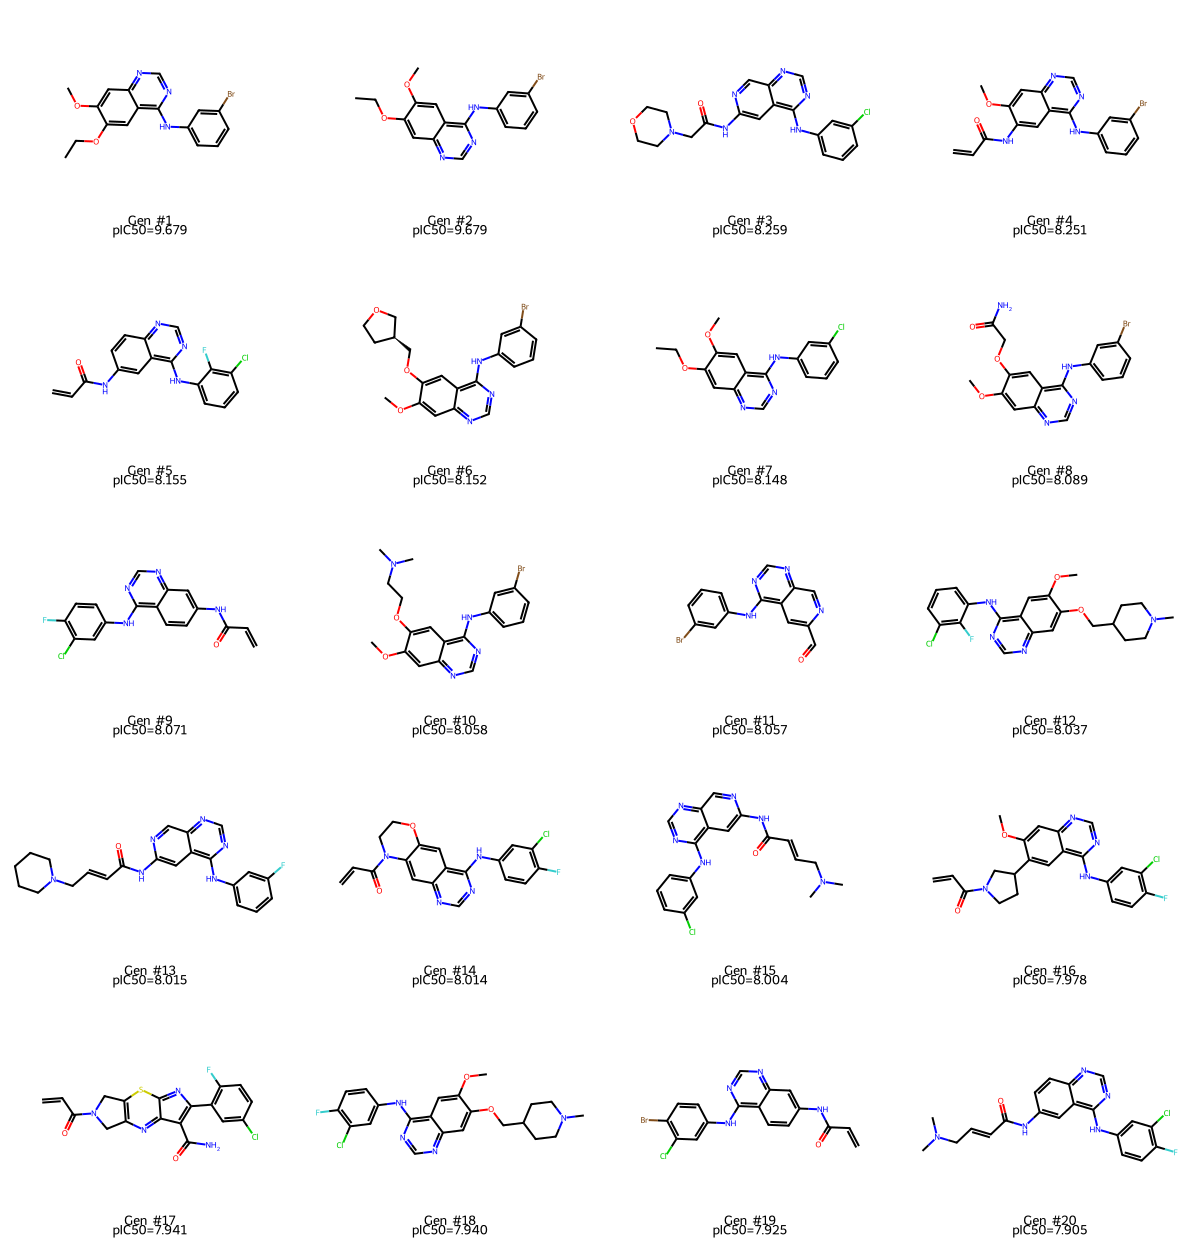

Top 20 novel EGFR inhibitor structures displayed
Image saved as top20_denovo_EGFR_hits.png


In [19]:
# Block 12: Visualize top generated novel EGFR inhibitor structures

from rdkit.Chem import Draw
from PIL import Image as PILImage

hit_mols = []
hit_labels = []

for idx, row in df_final_hits.head(20).iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        hit_mols.append(mol)
        hit_labels.append(
            f"Gen #{idx}\npIC50={row['predicted_pIC50']:.3f}"
        )

if len(hit_mols) > 0:
    img = Draw.MolsToGridImage(
        hit_mols,
        molsPerRow=4,
        subImgSize=(300, 250),
        legends=hit_labels,
        returnPNG=False
    )

    if isinstance(img, PILImage.Image):
        img.save('top20_denovo_EGFR_hits.png')
        display(img)
    else:
        with open('top20_denovo_EGFR_hits.png', 'wb') as f:
            f.write(img)
        display(PILImage.open('top20_denovo_EGFR_hits.png'))

    print("Top 20 novel EGFR inhibitor structures displayed")
    print("Image saved as top20_denovo_EGFR_hits.png")
else:
    print("No hits to visualize — try adjusting threshold or temperature")

Meaning of Block 12:

Same molecular structure visualization approach used in Practical 3 Block 9 — RDKit's Draw.MolsToGridImage() converts SMILES into 2D chemical structure diagrams arranged in a 4×5 grid.
Labels now read "Gen #1", "Gen #2" etc. — distinguishing these as generated molecules, not hits selected from an existing library (as in Practical 3's "Hit #1", "Hit #2").
The isinstance(img, PILImage.Image) check handles both old and new RDKit versions — same fix applied in Practical 3 Block 9 to prevent the AttributeError: 'Image' object has no attribute 'save' error.
What to look for in this image: compare the structural patterns in these generated molecules against the top hits from Practical 3 (Virtual Screening). Do the generated molecules contain similar pharmacophoric features — quinazoline rings, aniline groups, halogens, sulfonamides? If yes, the LSTM successfully learned real EGFR pharmacophore patterns from the fine-tuning data. If the structures look completely different from known EGFR inhibitors, the model may have learned general drug-like chemistry without adequately learning EGFR-specific patterns — in which case more fine-tuning epochs or a larger fine-tuning set would help.

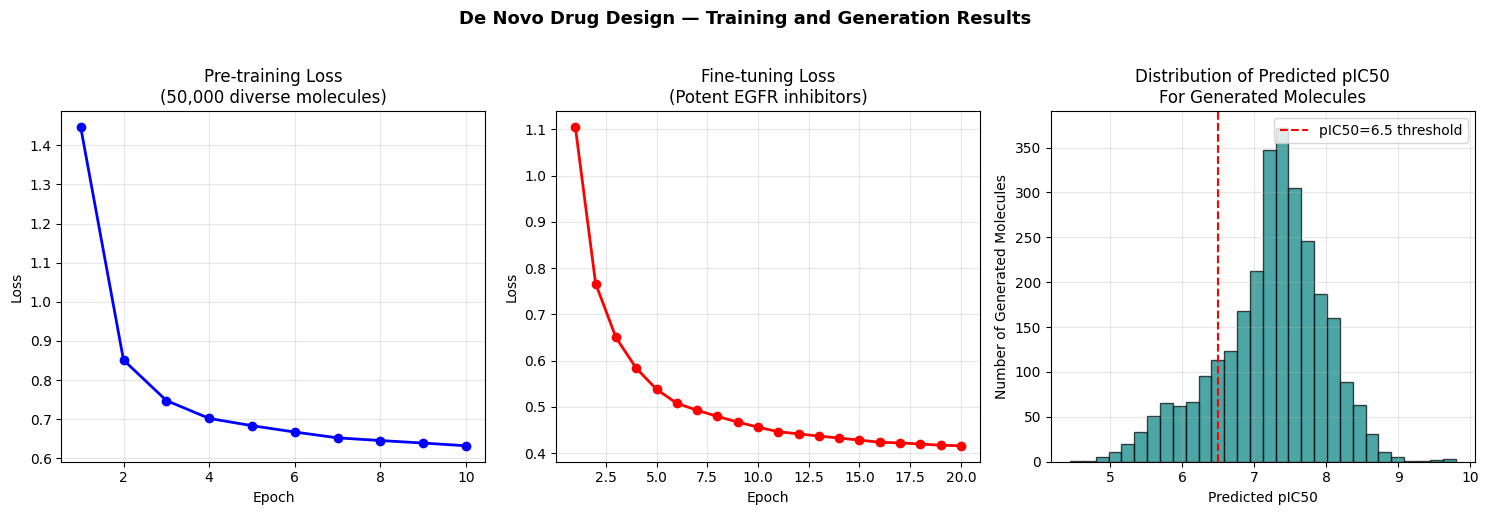

DE NOVO DRUG DESIGN — COMPLETE SUMMARY
RF Scoring Model: R²=0.736, RMSE=0.734
Pre-training: 10 epochs on 50000 molecules
Fine-tuning: 20 epochs on 6210 potent EGFR inhibitors
Molecules generated: 5000
Valid SMILES rate: 71.9%
Novel molecules: 2850 (novelty rate: 79.3%)
Drug-like hits (pIC50>=6.5): 744
Top predicted pIC50: 9.679


In [20]:
# Block 13: Training loss visualization and generation statistics

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(range(1, pretrain_epochs+1), pretrain_losses,
             'b-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Pre-training Loss\n(50,000 diverse molecules)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, finetune_epochs+1), finetune_losses,
             'r-o', linewidth=2, markersize=6)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Fine-tuning Loss\n(Potent EGFR inhibitors)')
axes[1].grid(True, alpha=0.3)

axes[2].hist(df_generated['predicted_pIC50'], bins=30,
             color='teal', edgecolor='black', alpha=0.7)
axes[2].axvline(x=6.5, color='red', linestyle='--',
                label='pIC50=6.5 threshold')
axes[2].set_xlabel('Predicted pIC50')
axes[2].set_ylabel('Number of Generated Molecules')
axes[2].set_title('Distribution of Predicted pIC50\nFor Generated Molecules')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('De Novo Drug Design — Training and Generation Results',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("="*55)
print("DE NOVO DRUG DESIGN — COMPLETE SUMMARY")
print("="*55)
print(f"RF Scoring Model: R²={r2:.3f}, RMSE={rmse:.3f}")
print(f"Pre-training: {pretrain_epochs} epochs on "
      f"{len(corpus_dataset)} molecules")
print(f"Fine-tuning: {finetune_epochs} epochs on "
      f"{len(finetune_dataset)} potent EGFR inhibitors")
print(f"Molecules generated: {len(generated_smiles)}")
print(f"Valid SMILES rate: {validity_rate:.1f}%")
print(f"Novel molecules: {novel_count} "
      f"(novelty rate: {novelty_rate:.1f}%)")
print(f"Drug-like hits (pIC50>=6.5): {len(df_druglike)}")
if len(df_druglike) > 0:
    print(f"Top predicted pIC50: "
          f"{df_druglike['predicted_pIC50'].max():.3f}")
print("="*55)

Meaning of Block 13:

Three side-by-side plots tell the complete story of Practical 4 visually.
Left plot (blue — Pre-training loss): shows how the model's prediction error decreased over 10 pre-training epochs on 50,000 diverse molecules. A steadily decreasing curve confirms the LSTM successfully learned SMILES grammar — early epochs show high loss (the model is guessing randomly), later epochs show low loss (the model has learned chemical language well). If the curve is flat or noisy, more pre-training epochs are needed.
Middle plot (red — Fine-tuning loss): shows loss during 20 fine-tuning epochs on potent EGFR inhibitors. Should start already lower than the end of pre-training (the model already knows chemistry) and continue decreasing as it learns EGFR-specific patterns. A steadily decreasing red curve confirms successful transfer learning.
Right plot (teal — pIC50 distribution): histogram of predicted pIC50 values for all valid novel generated molecules. Compare this distribution to the equivalent histogram from Practical 3 (Virtual Screening of ZINC library) — if the LSTM's generation is EGFR-biased, this distribution should be shifted to the right (higher pIC50 values) compared to the random ZINC library, confirming that fine-tuning successfully biased generation toward more potent EGFR inhibitor chemical space.
The final summary block consolidates all key metrics in one place — RF model performance, LSTM training details, generation statistics, and final hit count — in the same professional report format used throughout the series.

In [23]:
# Block 14: Save all results and download files

df_final_hits.to_excel('denovo_EGFR_hits_final.xlsx', index=True)

import joblib
joblib.dump(rf_model, 'egfr_denovo_rf_model.pkl')

torch.save(model.state_dict(), 'egfr_lstm_model.pth')

vocab_data = {
    'vocab': vocab,
    'char_to_idx': char_to_idx,
    'idx_to_char': idx_to_char
}
import json
with open('egfr_lstm_vocabulary.json', 'w') as f:
    json.dump({
        'vocab': vocab,
        'char_to_idx': char_to_idx,
        'idx_to_char': {str(k): v for k, v in idx_to_char.items()}
    }, f)

from google.colab import files
files.download('denovo_EGFR_hits_final.xlsx')
files.download('egfr_denovo_rf_model.pkl')
files.download('egfr_lstm_model.pth')
files.download('egfr_lstm_vocabulary.json')
files.download('top20_denovo_EGFR_hits.png')

print("="*55)
print("ALL FILES SAVED AND DOWNLOADED")
print("="*55)
print(f"Drug-like hits (all filters passed): {len(df_final_hits)}")  # ← ADD THIS LINE HERE
print("="*55)
print("Files saved:")
print("1. denovo_EGFR_hits_final.xlsx — Novel drug-like EGFR candidates")
print("2. egfr_denovo_rf_model.pkl — RF scoring model")
print("3. egfr_lstm_model.pth — Trained LSTM generative model")
print("4. egfr_lstm_vocabulary.json — SMILES vocabulary")
print("5. top20_denovo_EGFR_hits.png — Structure visualization")
print("="*55)
print("\nUpload to GitHub:")
print("Excel_Files/ → denovo_EGFR_hits_final.xlsx")
print("models/ → egfr_denovo_rf_model.pkl")
print("models/ → egfr_lstm_model.pth")
print("models/ → egfr_lstm_vocabulary.json")
print("="*55)
print("\nPRACTICAL 4 COMPLETE")
print("Target: EGFR (CHEMBL203) — Non-Small Cell Lung Cancer")
print("Novel drug candidates generated by AI — never existed before")
print("="*55)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ALL FILES SAVED AND DOWNLOADED
Drug-like hits (all filters passed): 178
Files saved:
1. denovo_EGFR_hits_final.xlsx — Novel drug-like EGFR candidates
2. egfr_denovo_rf_model.pkl — RF scoring model
3. egfr_lstm_model.pth — Trained LSTM generative model
4. egfr_lstm_vocabulary.json — SMILES vocabulary
5. top20_denovo_EGFR_hits.png — Structure visualization

Upload to GitHub:
Excel_Files/ → denovo_EGFR_hits_final.xlsx
models/ → egfr_denovo_rf_model.pkl
models/ → egfr_lstm_model.pth
models/ → egfr_lstm_vocabulary.json

PRACTICAL 4 COMPLETE
Target: EGFR (CHEMBL203) — Non-Small Cell Lung Cancer
Novel drug candidates generated by AI — never existed before


Meaning of Block 14:

Meaning of Block 14:

Purpose:
This is the final block of Practical 4. It permanently saves every deliverable produced by the complete de novo drug design pipeline — the final hit list, the trained RF scoring model, the trained LSTM generative model, the SMILES vocabulary, and the structure visualization image — and downloads all of them to your desktop for uploading to GitHub.

What data comes IN:

df_final_hits — the fully filtered, ranked final hit list produced by Block 11E — molecules that passed all six quality stages: validity, novelty, RF scoring (pIC50 ≥ 6.5), Lipinski Rule of Five, QED ≥ 0.6, SA Score ≤ 4.0, and PAINS-free.
rf_model — the trained Random Forest scoring model from Block 2.
model — the trained LSTM generative model from Blocks 7 and 8.
vocab, char_to_idx, idx_to_char — the SMILES vocabulary dictionaries built in Block 4.
top20_denovo_EGFR_hits.png — the molecular structure grid image saved to Colab's temporary storage in Block 12.

What happens inside — line by line:

df_final_hits.to_excel('denovo_EGFR_hits_final.xlsx', index=True) — saves the complete final hit list as an Excel file in Colab's temporary storage. index=True includes the hit ranking numbers (1, 2, 3...) as the first column in the Excel file — important so anyone opening the file immediately sees the ranked order of candidates without needing to sort manually. This Excel file is the primary scientific deliverable of the entire practical — a ranked, filterable list of novel, drug-like, predicted EGFR inhibitors that could be handed directly to an experimental pharmacologist for follow-up testing.
joblib.dump(rf_model, 'egfr_denovo_rf_model.pkl') — saves the trained Random Forest scoring model using joblib's efficient serialization format. This model learned from 13,577 known EGFR inhibitors and can be reloaded in any future session to score new compounds without retraining — a process that takes 3–5 minutes each time. Saving it permanently means any researcher or future student can reuse this scoring capability instantly.
torch.save(model.state_dict(), 'egfr_lstm_model.pth') — saves the trained LSTM generative model's weights in PyTorch's native .pth format. model.state_dict() extracts only the learned numerical weights from the model (not the architecture code) — this is the standard, recommended PyTorch approach for saving trained models. .pth is PyTorch's standard file extension (short for PyTorch). This file allows the fine-tuned LSTM to be reloaded in future sessions to generate more novel molecules without going through the 25–35 minute training process again.
import json — loads Python's built-in JSON handling library for saving the vocabulary dictionaries as human-readable text files.
with open('egfr_lstm_vocabulary.json', 'w') as f: json.dump({...}, f) — saves the three vocabulary dictionaries (vocab, char_to_idx, idx_to_char) as a JSON file. This is critically important: the LSTM model weights saved in egfr_lstm_model.pth are completely meaningless without the vocabulary — when reloading the model to generate molecules, you must use the exact same character-to-index mappings it was trained with. Without this file, character 'C' might map to a different number than it did during training, causing the model to generate complete gibberish instead of valid SMILES. {str(k): v for k, v in idx_to_char.items()} converts integer dictionary keys to strings — this is required because JSON format only allows string keys, not integer keys.
from google.colab import files — loads Colab's file transfer tool that bridges Colab's temporary cloud storage and your local computer.
files.download('denovo_EGFR_hits_final.xlsx') — triggers your browser to download the Excel hit list directly to your computer's Downloads folder.
files.download('egfr_denovo_rf_model.pkl') — downloads the RF model.
files.download('egfr_lstm_model.pth') — downloads the LSTM weights.
files.download('egfr_lstm_vocabulary.json') — downloads the vocabulary file.
files.download('top20_denovo_EGFR_hits.png') — downloads the molecular structure grid image saved by Block 12.
print(f"Drug-like hits (all filters passed): {len(df_final_hits)}") — displays the definitive final count of molecules that survived all six quality filters. This single number summarizes the entire pipeline's output — from 5,000 generated molecules down to however many passed every filter. This is the number students should record in their lab reports as the final output of the de novo design campaign.
The formatted print block at the end serves as the official completion message — listing all five saved files with their names and purposes, the GitHub upload instructions for permanent storage, and a closing statement confirming the practical is complete with the disease target and the significance of the result.